# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Global Placement Dataset](https://www.kaggle.com/datasets/rakesh630/global-student-placement-2025-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/rakesh630/global-student-placement-2025-dataset/global_placement.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('global_placement.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed,104124.367838
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed,80586.838313
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed,114444.318097
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed,120000.000000
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed,120000.000000


## last Five row

In [4]:
df.tail()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status,salary
9995,8.040882,0,Tier 3,USA,100-300,2,98.120449,80.866213,Data Science,Manufacturing,6.298524,Placed,109831.584346
9996,5.401324,3,Tier 1,UK,100-300,1,68.622854,83.458035,Data Science,Consulting,7.352717,Not Placed,0.000000
9997,6.435747,0,Tier 3,UK,300+,2,69.067773,50.992745,Core CS,Other,3.871205,Placed,69818.819355
9998,7.396612,1,Tier 3,Germany,100-300,3,45.050463,86.807882,Cloud,Finance,3.687731,Placed,82797.577423
9999,7.515511,3,Tier 2,UK,300+,4,66.947232,46.385843,AI/ML,Manufacturing,4.181389,Placed,105387.859101


## Shape of our dataset

In [5]:
df.shape

(10000, 13)

## List out all columns

In [6]:
df.columns

Index(['cgpa', 'backlogs', 'college_tier', 'country',
       'university_ranking_band', 'internship_count', 'aptitude_score',
       'communication_score', 'specialization', 'industry',
       'internship_quality_score', 'placement_status', 'salary'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
salary                      float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
 12  salary                    10000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1015.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
salary                      0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score,salary
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436,55442.146458
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975,47995.029325
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000,0.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656,0.000000
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335,63431.317260
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400,100600.617480
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000,120000.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

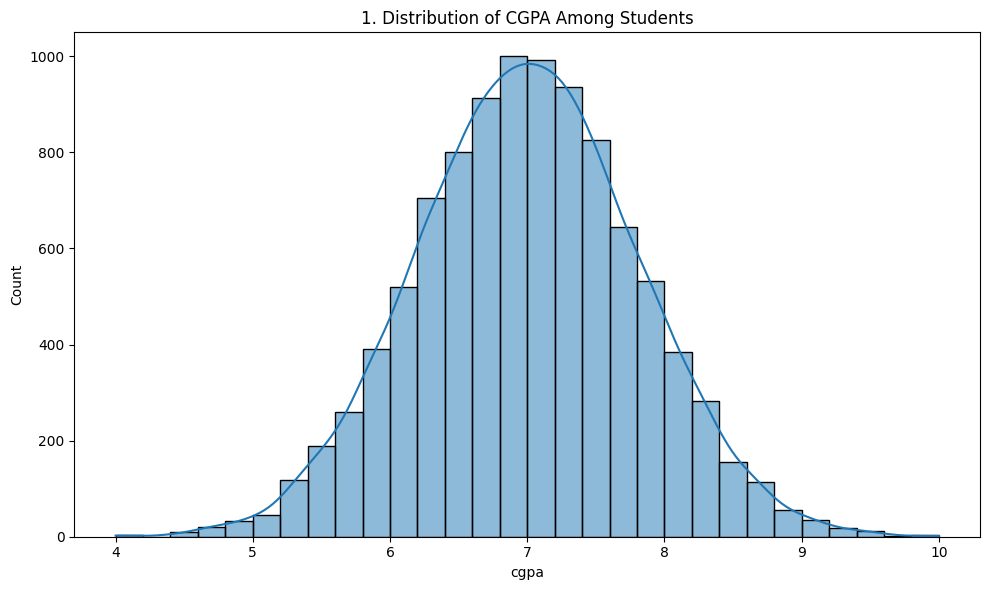

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['cgpa'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of CGPA Among Students')
show_fig()
plot_no += 1

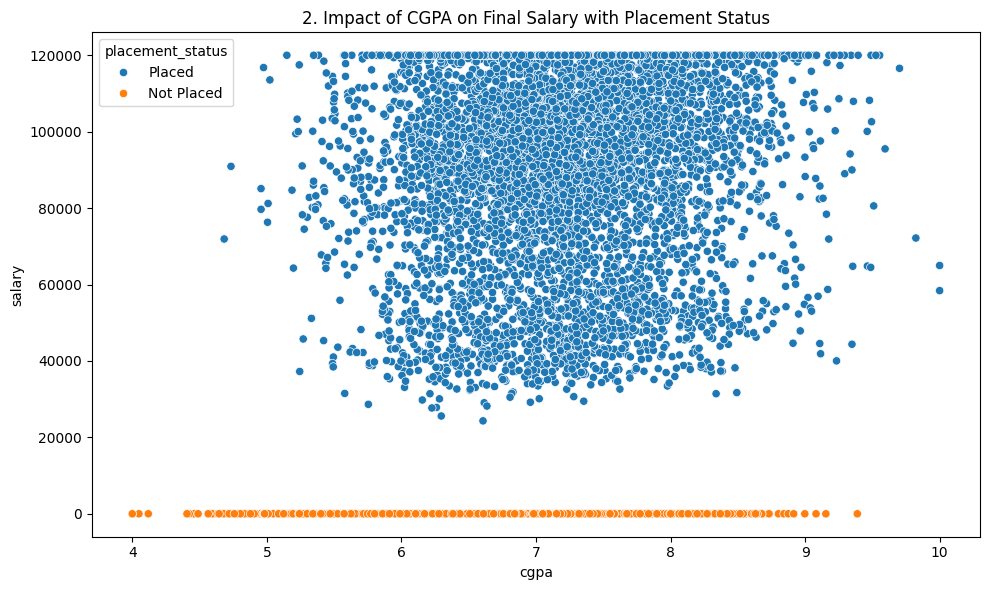

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='cgpa', y='salary', hue='placement_status')
plt.title(f'{plot_no}. Impact of CGPA on Final Salary with Placement Status')
show_fig()
plot_no += 1

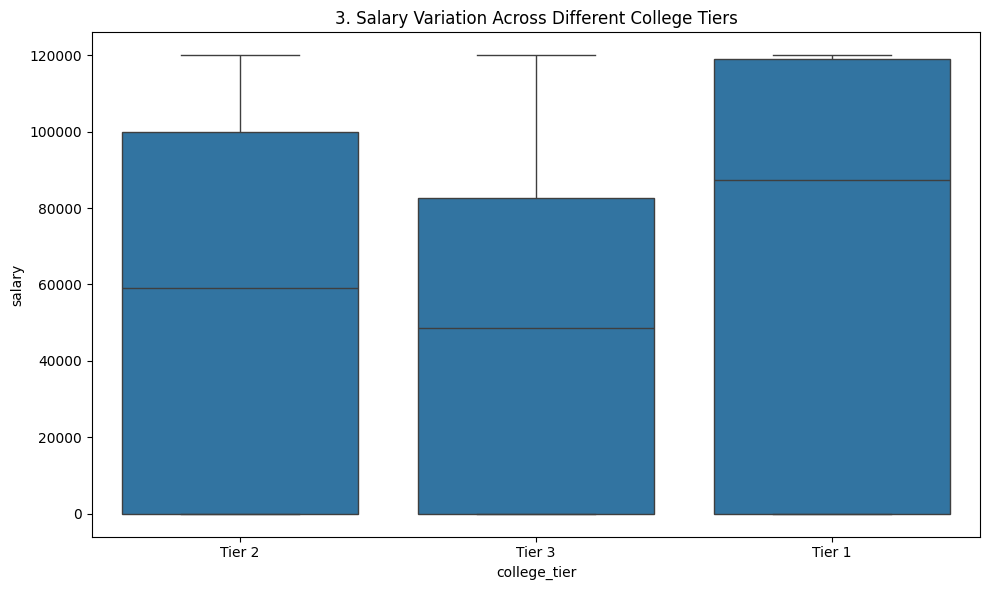

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='college_tier', y='salary')
plt.title(f'{plot_no}. Salary Variation Across Different College Tiers')
show_fig()
plot_no += 1

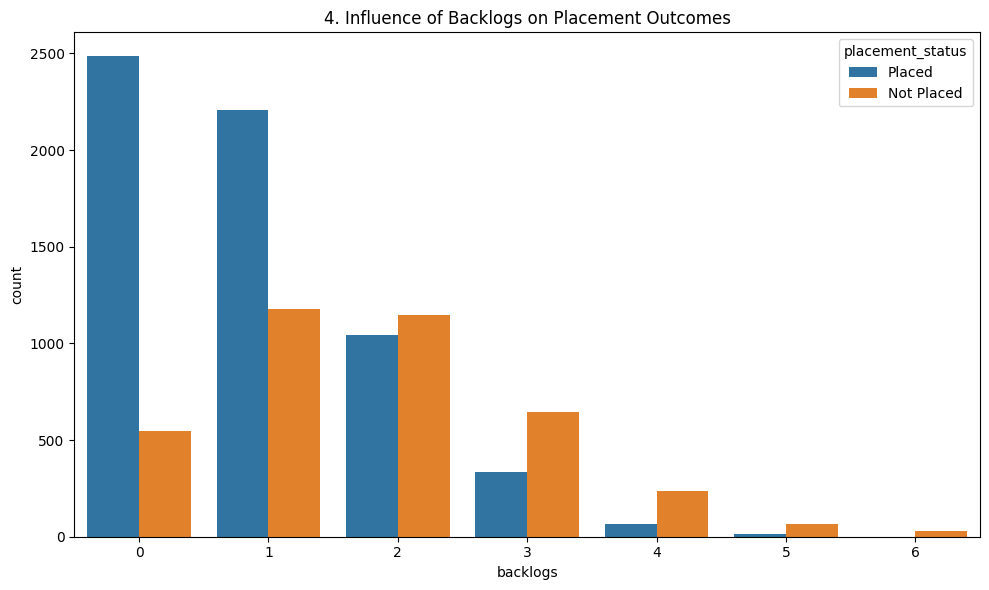

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='backlogs', hue='placement_status')
plt.title(f'{plot_no}. Influence of Backlogs on Placement Outcomes')
show_fig()
plot_no += 1

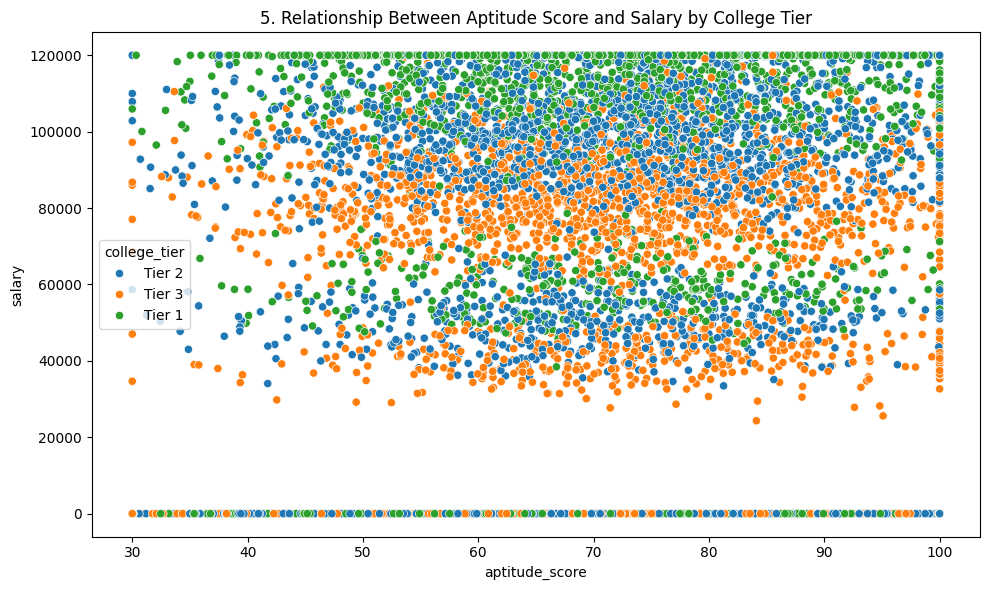

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='aptitude_score', y='salary', hue='college_tier')
plt.title(f'{plot_no}. Relationship Between Aptitude Score and Salary by College Tier')
show_fig()
plot_no += 1

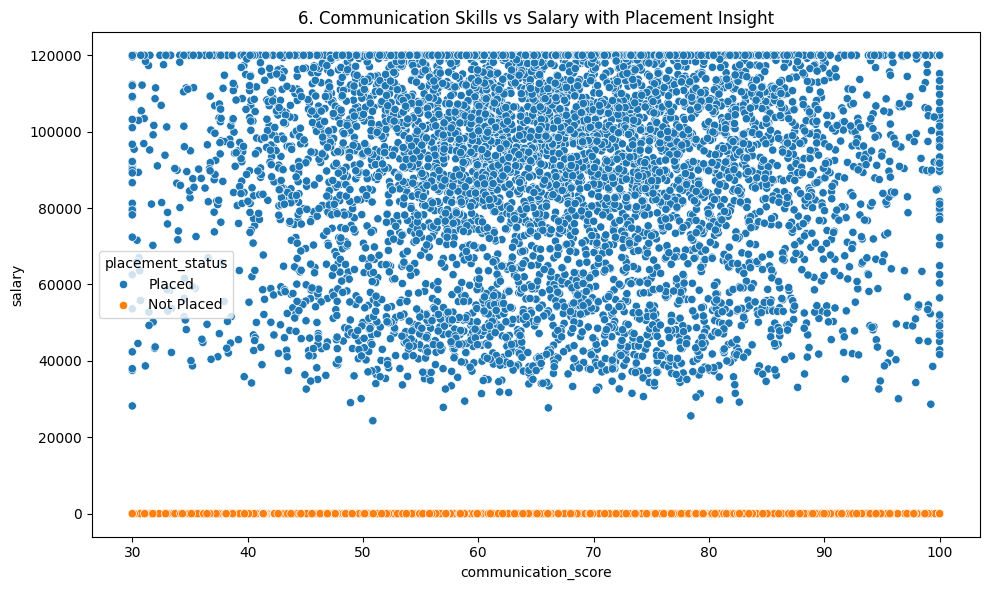

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='communication_score', y='salary', hue='placement_status')
plt.title(f'{plot_no}. Communication Skills vs Salary with Placement Insight')
show_fig()
plot_no += 1

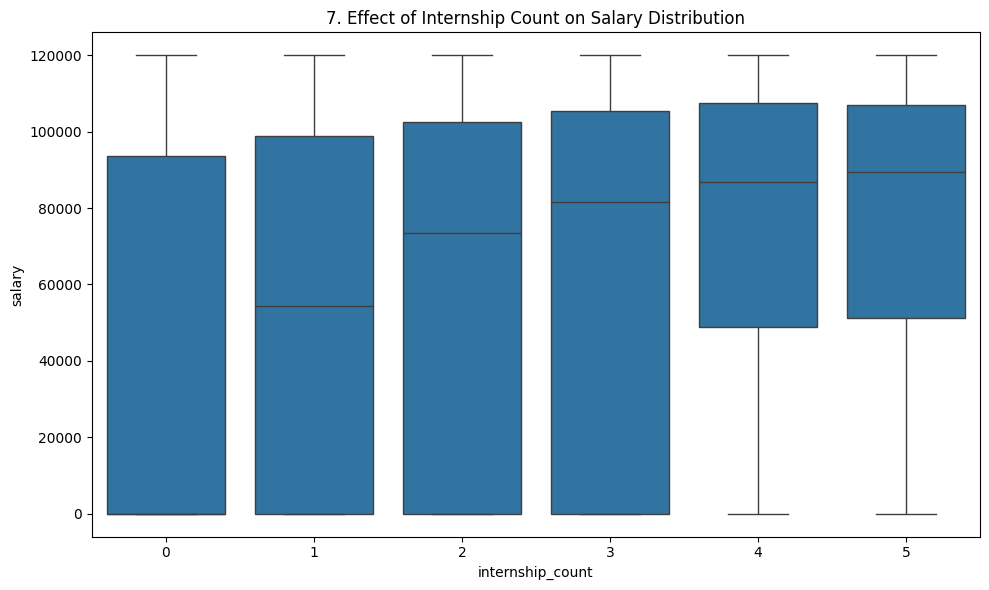

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='internship_count', y='salary')
plt.title(f'{plot_no}. Effect of Internship Count on Salary Distribution')
show_fig()
plot_no += 1

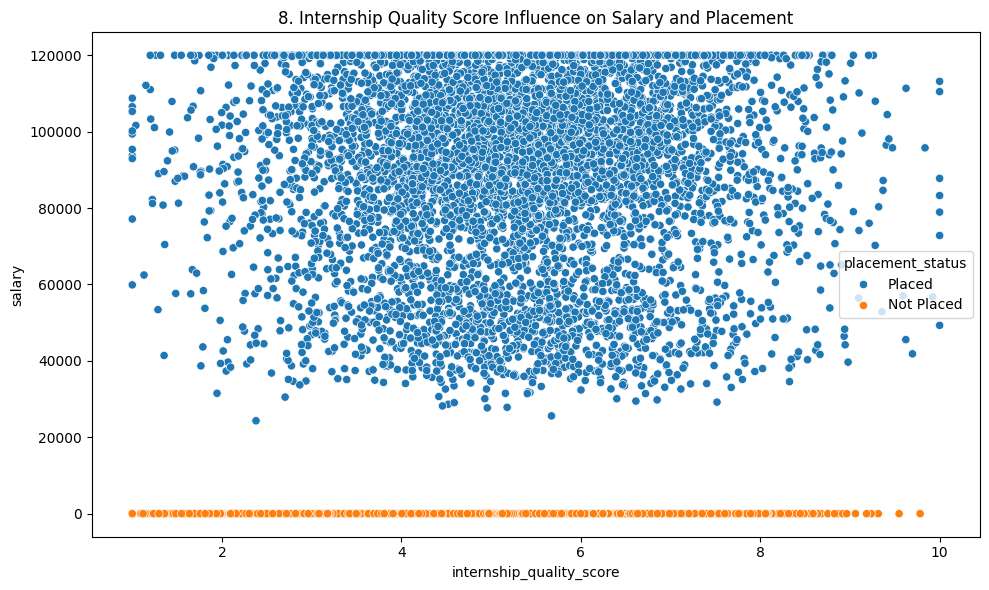

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='internship_quality_score', y='salary', hue='placement_status')
plt.title(f'{plot_no}. Internship Quality Score Influence on Salary and Placement')
show_fig()
plot_no += 1

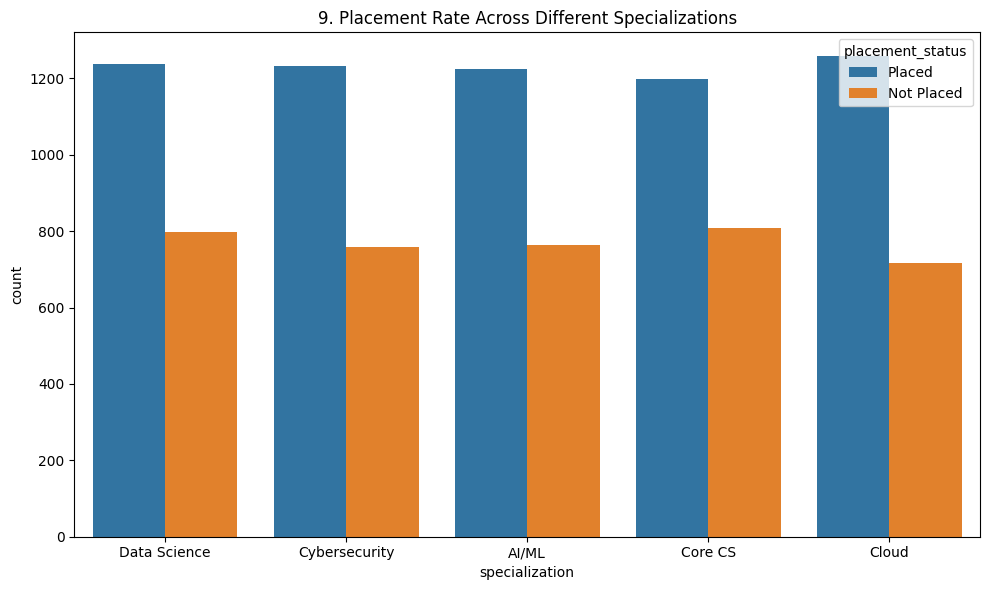

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='specialization', hue='placement_status')
plt.title(f'{plot_no}. Placement Rate Across Different Specializations')
show_fig()
plot_no += 1

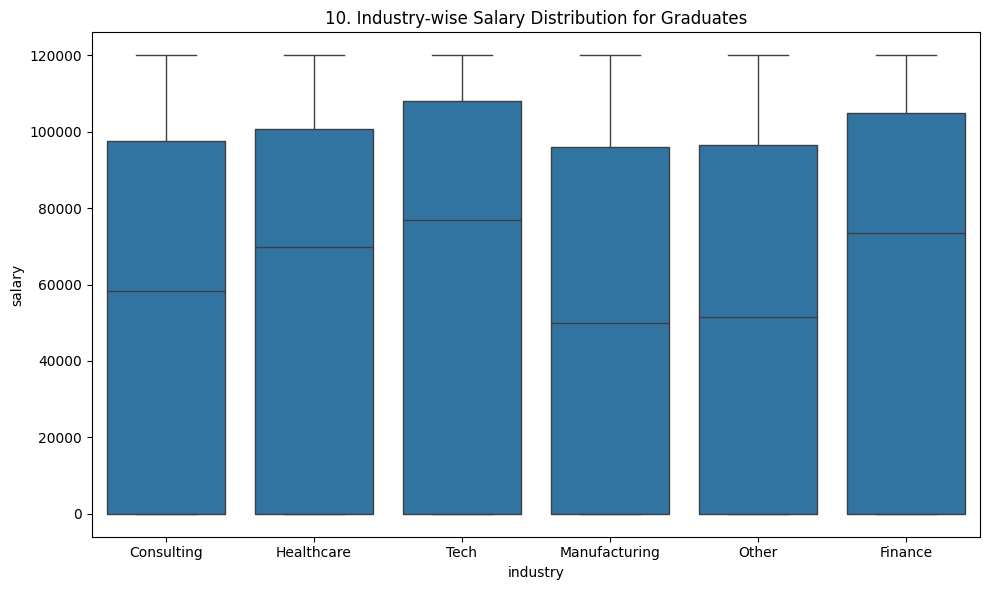

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='industry', y='salary')
plt.title(f'{plot_no}. Industry-wise Salary Distribution for Graduates')
show_fig()
plot_no += 1

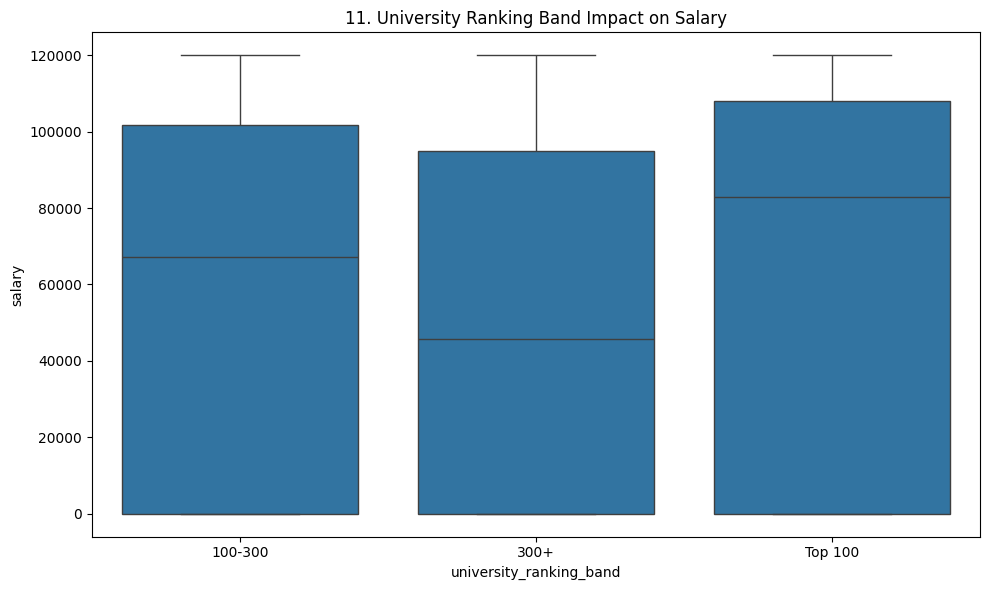

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='university_ranking_band', y='salary')
plt.title(f'{plot_no}. University Ranking Band Impact on Salary')
show_fig()
plot_no += 1

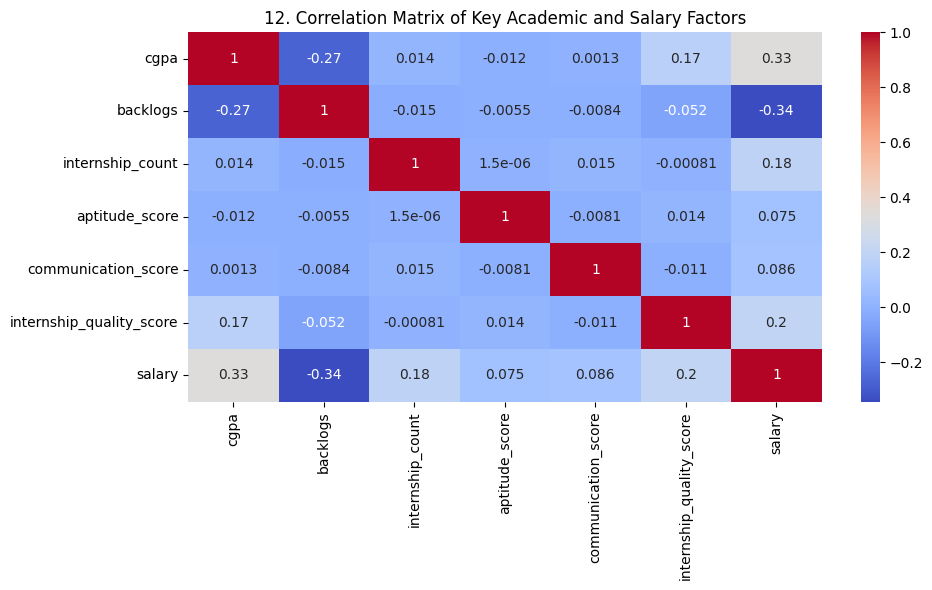

In [24]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[['cgpa','backlogs','internship_count','aptitude_score','communication_score','internship_quality_score','salary']].corr(), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Matrix of Key Academic and Salary Factors')
show_fig()
plot_no += 1

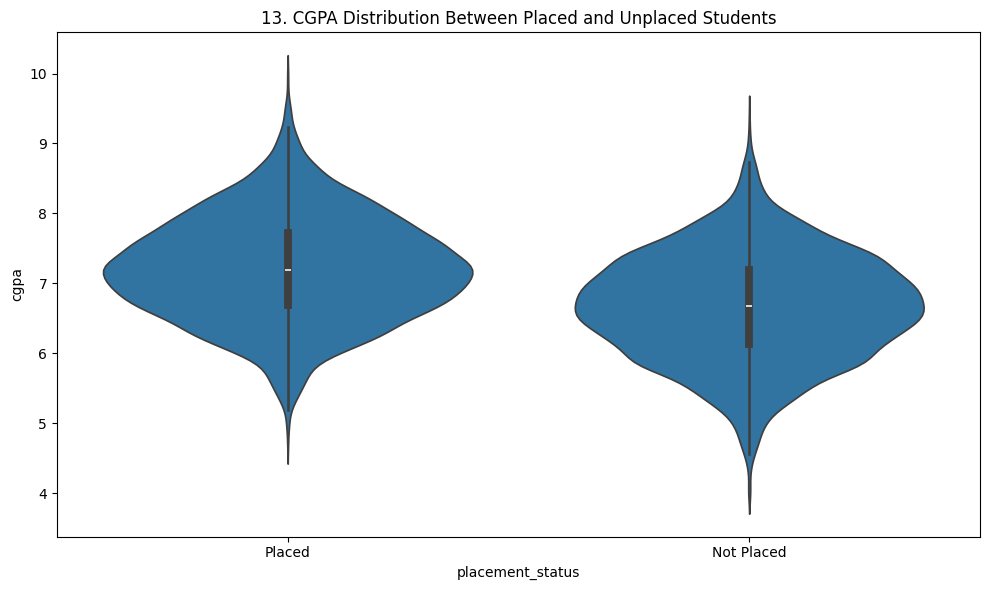

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='placement_status', y='cgpa')
plt.title(f'{plot_no}. CGPA Distribution Between Placed and Unplaced Students')
show_fig()
plot_no += 1

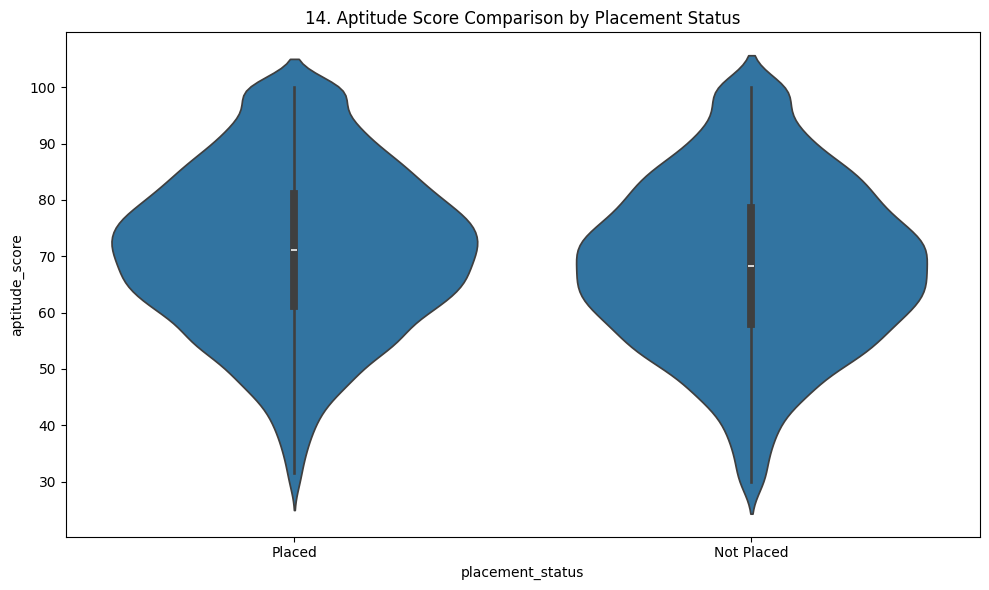

In [26]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='placement_status', y='aptitude_score')
plt.title(f'{plot_no}. Aptitude Score Comparison by Placement Status')
show_fig()
plot_no += 1

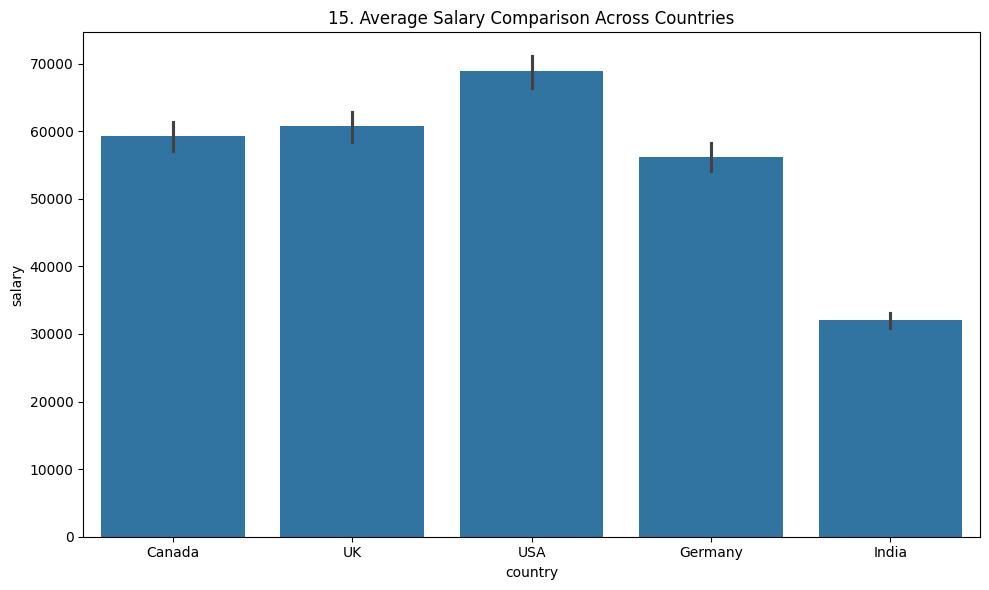

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='country', y='salary')
plt.title(f'{plot_no}. Average Salary Comparison Across Countries')
show_fig()
plot_no += 1

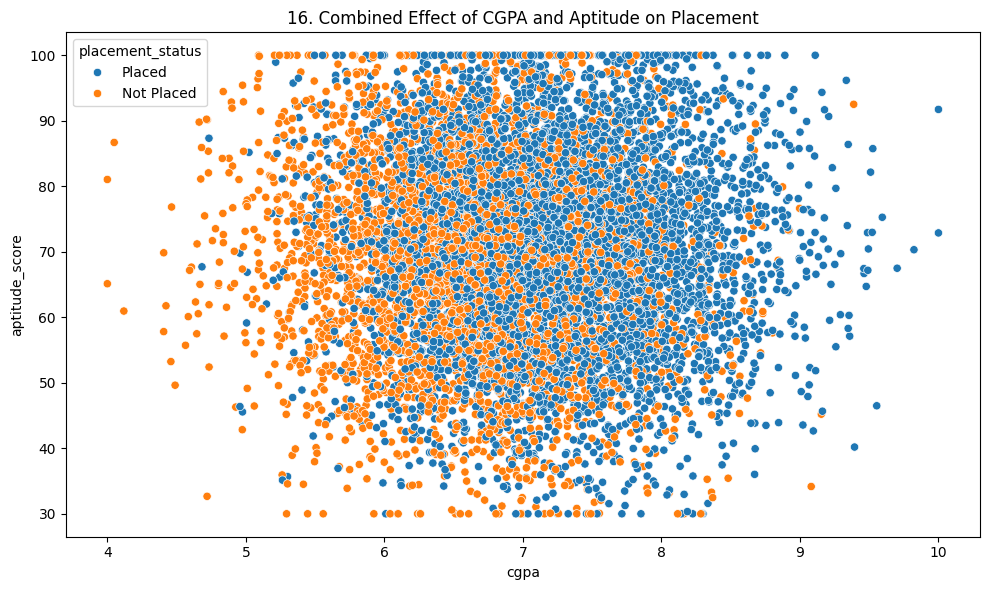

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='cgpa', y='aptitude_score', hue='placement_status')
plt.title(f'{plot_no}. Combined Effect of CGPA and Aptitude on Placement')
show_fig()
plot_no += 1

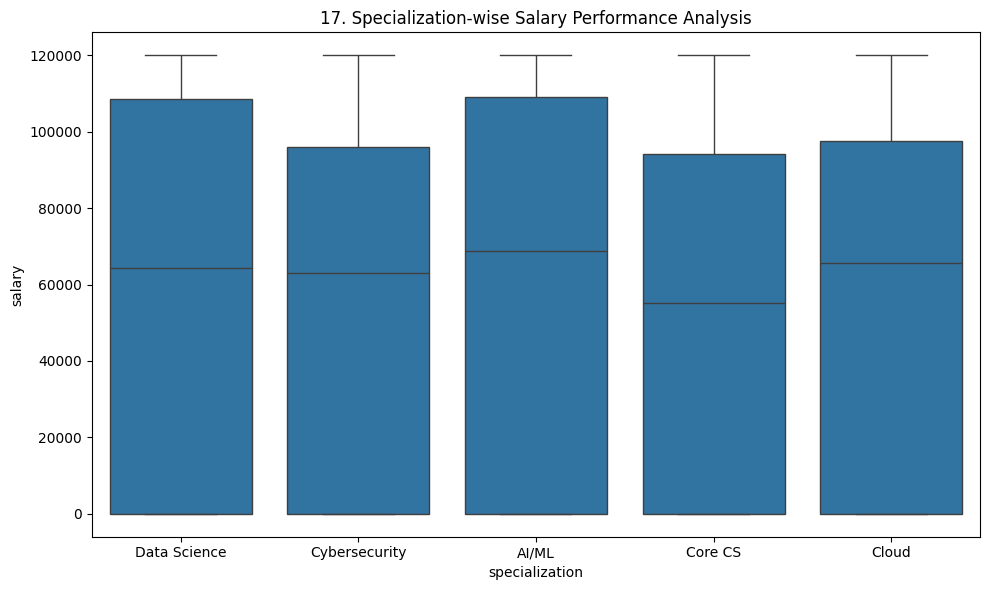

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='specialization', y='salary')
plt.title(f'{plot_no}. Specialization-wise Salary Performance Analysis')
show_fig()
plot_no += 1

# Model Training

## Encode categorical features

In [30]:
df_model = df.copy()
le_dict = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

## Define features and target

In [31]:
X = df_model.drop('placement_status', axis=1)
y = df_model['placement_status']

## Split the dataset

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale the numerical features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression model

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Predict on test data

In [35]:
y_pred = model.predict(X_test)

## Print accuracy score

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy Score:", accuracy)

Model Accuracy Score: 1.0


## Plot Confusion Matrix

<Figure size 600x500 with 0 Axes>

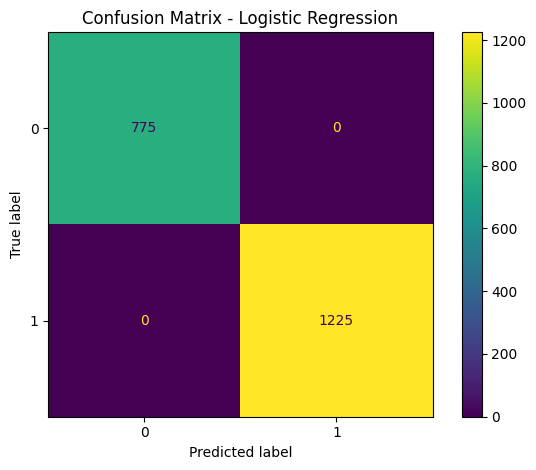

In [37]:
fig = plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()